# Phase 2 — Baseline CNN from Scratch

Building a simple CNN with no pretrained weights, no Dropout, no BatchNorm, no augmentation.
The goal here is a clean baseline — not the best model possible.

Architecture: 4 Conv blocks (32 → 64 → 128 → 128 filters) → Flatten → Dense(64) → Dense(4)
Total trainable parameters: **765,444** (under 1M limit)

**Figures saved to** `outputs/figures/phase2_*.png`  
**Best model saved to** `saved_models/baseline_cnn_best.keras`

In [8]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.21.0
GPU available: True


In [9]:
if Path.cwd().name == 'notebooks':
    os.chdir('..')

DATA_ROOT  = Path('../Data')
TRAIN_DIR  = DATA_ROOT / 'TRAIN'
TEST_DIR   = DATA_ROOT / 'TEST'
FIGS       = Path('outputs/figures')
LOGS       = Path('outputs/logs')
MODELS_DIR = Path('saved_models')

for d in [FIGS, LOGS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASSES    = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
COLORS     = ['#4FA3D1', '#5DBB8A', '#E8A838', '#D15F4F']
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 0.0001

print('Paths OK')
print(f'Image size : {IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {EPOCHS}')
print(f'LR         : {LR}')

Paths OK
Image size : (128, 128)
Batch size : 32
Epochs     : 30
LR         : 0.0001


## 1. Data generators

No augmentation in this phase — just rescale to [0, 1] and resize.  
80/20 split same as Phase 1.

In [10]:
# no augmentation — just rescale
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.20
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nTrain  : {train_gen.samples:,} images')
print(f'Val    : {val_gen.samples:,} images')
print(f'Test   : {test_gen.samples:,} images')
print(f'\nClass index map: {train_gen.class_indices}')

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.

Train  : 7,968 images
Val    : 1,989 images
Test   : 2,487 images

Class index map: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


## 2. Model architecture

4 convolutional blocks, each with a 3×3 Conv layer, ReLU activation, and 2×2 MaxPool.  
No Dropout, no BatchNorm, no anything fancy — pure baseline.

```
Input  (128, 128, 3)
  ↓  Conv2D(32,  3×3, ReLU) → MaxPool(2×2)   →  64 × 64 × 32
  ↓  Conv2D(64,  3×3, ReLU) → MaxPool(2×2)   →  32 × 32 × 64
  ↓  Conv2D(128, 3×3, ReLU) → MaxPool(2×2)   →  16 × 16 × 128
  ↓  Conv2D(128, 3×3, ReLU) → MaxPool(2×2)   →   8 ×  8 × 128
  ↓  Flatten                                  →  8192
  ↓  Dense(64, ReLU)
  ↓  Dense(4,  Softmax)
```

In [11]:
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # block 1
        layers.Conv2D(32,  (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # block 2
        layers.Conv2D(64,  (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # block 4
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # classifier head
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline_cnn')
    return model


model = build_baseline_cnn()
model.summary()

total_params = model.count_params()
print(f'Total trainable parameters : {total_params:,}')
print(f'Under 1M limit             : {total_params < 1_000_000}')


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 765,444 (2.92 MB)

 Trainable params: 765,444 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters : 765,444
Under 1M limit             : True


## 3. Training

Optimizer: Adam (lr=0.0001)  
Loss: categorical cross-entropy  
The best model (by val_accuracy) is saved automatically.

In [12]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint(
        str(MODELS_DIR / 'baseline_cnn_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(str(LOGS / 'baseline_cnn.csv'))
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1779880467.281717     496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19710__.52


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.2540 - loss: 1.3879
Epoch 1: val_accuracy improved from None to 0.26647, saving model to saved_models/baseline_cnn_best.keras

Epoch 1: finished saving model to saved_models/baseline_cnn_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 51s 192ms/step - accuracy: 0.2460 - loss: 1.3871 - val_accuracy: 0.2665 - val_loss: 1.3859
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.2572 - loss: 1.3845
Epoch 2: val_accuracy improved from 0.26647 to 0.30669, saving model to saved_models/baseline_cnn_best.keras

Epoch 2: finished saving model to saved_models/baseline_cnn_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.2765 - loss: 1.3759 - val_accuracy: 0.3067 - val_loss: 1.3323
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3968 - loss: 1.2595
Epoch 3: val_accuracy improved from 0.30669 to 0.48115, saving model to saved_models/baseline_cnn_best.keras

Epoch 3: finished saving model to save

## 4. Training curves

Loss and accuracy over every epoch for both train and val.

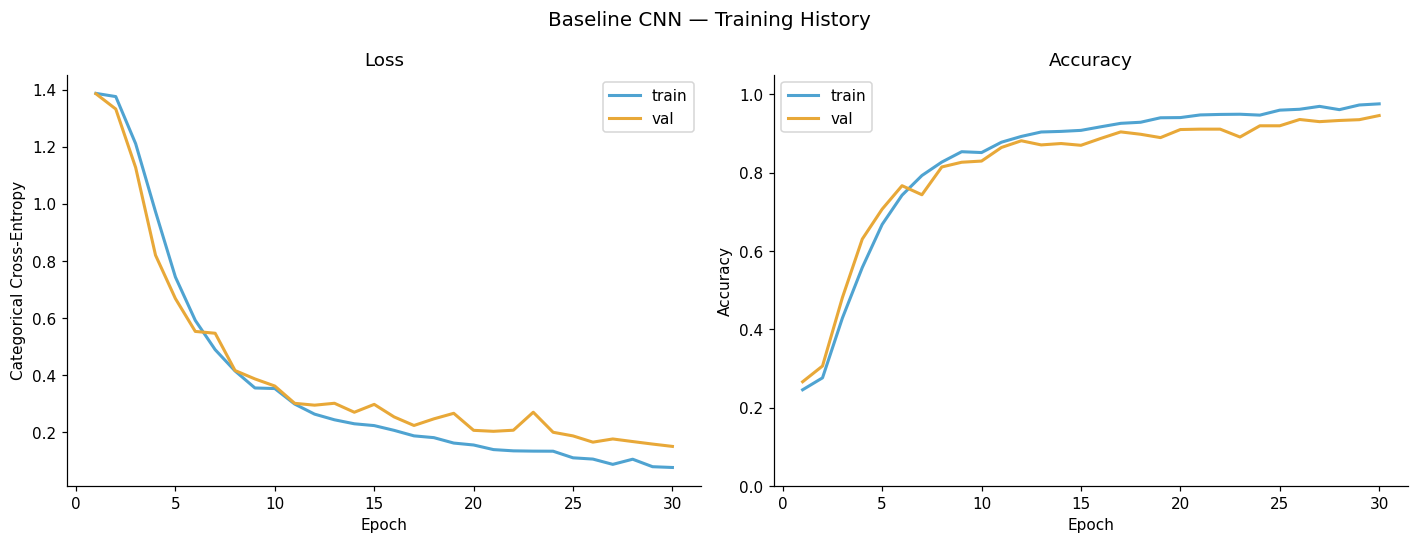

saved -> outputs/figures/phase2_01_training_curves.png

Final epoch  —  train loss: 0.0773  train acc: 0.9755
             val loss: 0.1511  val acc: 0.9457

Best val acc : 0.9457  at epoch 30


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'],     label='train', color='#4FA3D1', lw=2)
ax1.plot(epochs_range, history.history['val_loss'], label='val',   color='#E8A838', lw=2)
ax1.set_title('Loss', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Cross-Entropy')
ax1.legend()

ax2.plot(epochs_range, history.history['accuracy'],     label='train', color='#4FA3D1', lw=2)
ax2.plot(epochs_range, history.history['val_accuracy'], label='val',   color='#E8A838', lw=2)
ax2.set_title('Accuracy', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.suptitle('Baseline CNN — Training History', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_01_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_01_training_curves.png')

# quick summary of final epoch
print(f"\nFinal epoch  —  train loss: {history.history['loss'][-1]:.4f}  "
      f"train acc: {history.history['accuracy'][-1]:.4f}")
print(f"             val loss: {history.history['val_loss'][-1]:.4f}  "
      f"val acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"\nBest val acc : {max(history.history['val_accuracy']):.4f}  "
      f"at epoch {history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1}")

## 5. Evaluation on TEST

Load the best saved checkpoint and run it on the TEST set.

In [14]:
best_model = tf.keras.models.load_model(MODELS_DIR / 'baseline_cnn_best.keras')

test_gen.reset()
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes

# overall accuracy
test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
print(f'\nTest loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

78/78 ━━━━━━━━━━━━━━━━━━━━ 57s 726ms/step

Test loss     : 0.6620
Test accuracy : 0.7953


### 5.1 Classification report

In [15]:
print(classification_report(y_true, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

  EOSINOPHIL       0.65      0.73      0.69       623
  LYMPHOCYTE       1.00      0.93      0.96       620
    MONOCYTE       0.97      0.76      0.85       620
  NEUTROPHIL       0.66      0.76      0.71       624

    accuracy                           0.80      2487
   macro avg       0.82      0.80      0.80      2487
weighted avg       0.82      0.80      0.80      2487



### 5.2 Confusion matrix

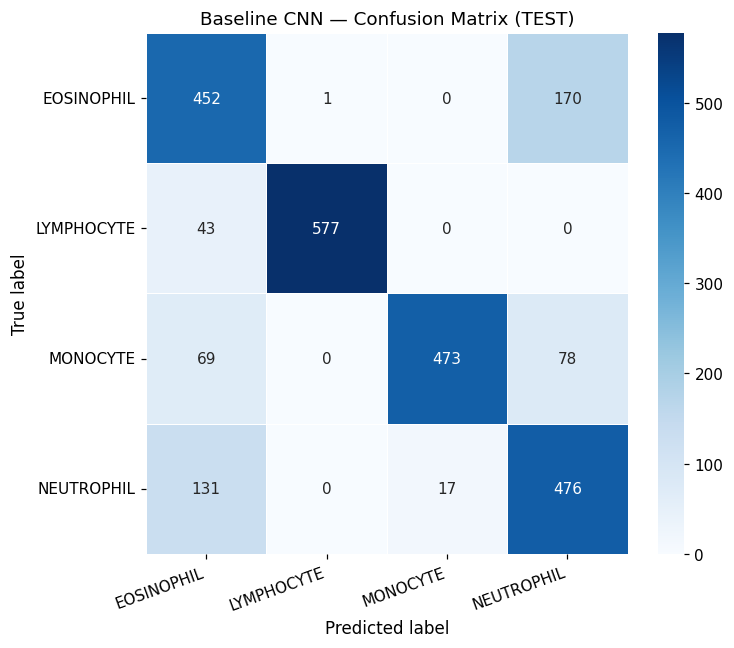

saved -> outputs/figures/phase2_02_confusion_matrix.png


In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
    linewidths=0.5
)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label',      fontsize=11)
ax.set_title('Baseline CNN — Confusion Matrix (TEST)', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_02_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_02_confusion_matrix.png')

### 5.3 ROC curves + AUC

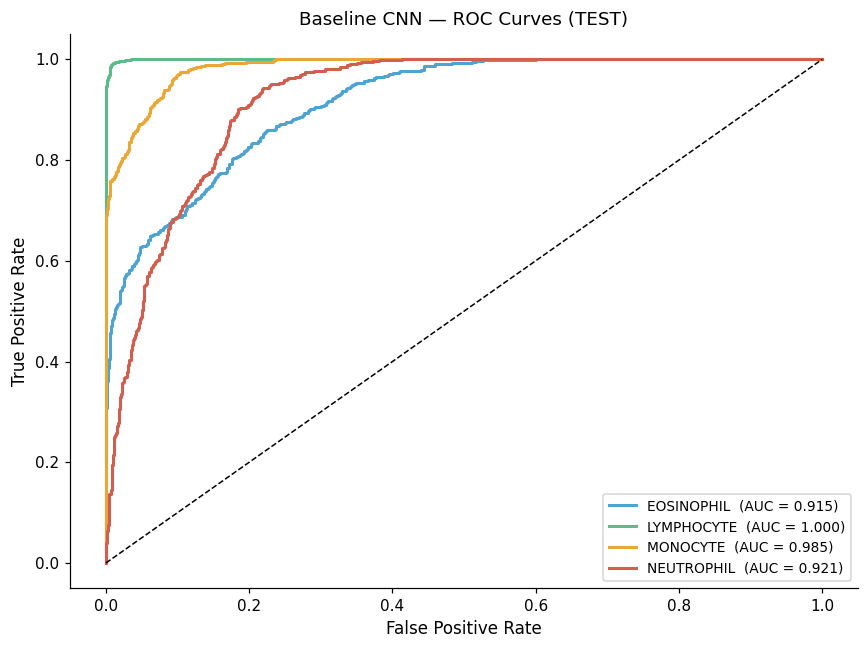

saved -> outputs/figures/phase2_03_roc_curves.png

AUC per class:
  EOSINOPHIL    : 0.9150
  LYMPHOCYTE    : 0.9996
  MONOCYTE      : 0.9848
  NEUTROPHIL    : 0.9215
  Macro avg   : 0.9552


In [17]:
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(8, 6))

auc_scores = {}
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('Baseline CNN — ROC Curves (TEST)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_03_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_03_roc_curves.png')

print('\nAUC per class:')
for cls, score in auc_scores.items():
    print(f'  {cls:<14}: {score:.4f}')
print(f'  Macro avg   : {np.mean(list(auc_scores.values())):.4f}')

### 5.4 Sample predictions from TEST

A few real test images with their true and predicted labels.  
Green title = correct, Red title = wrong.

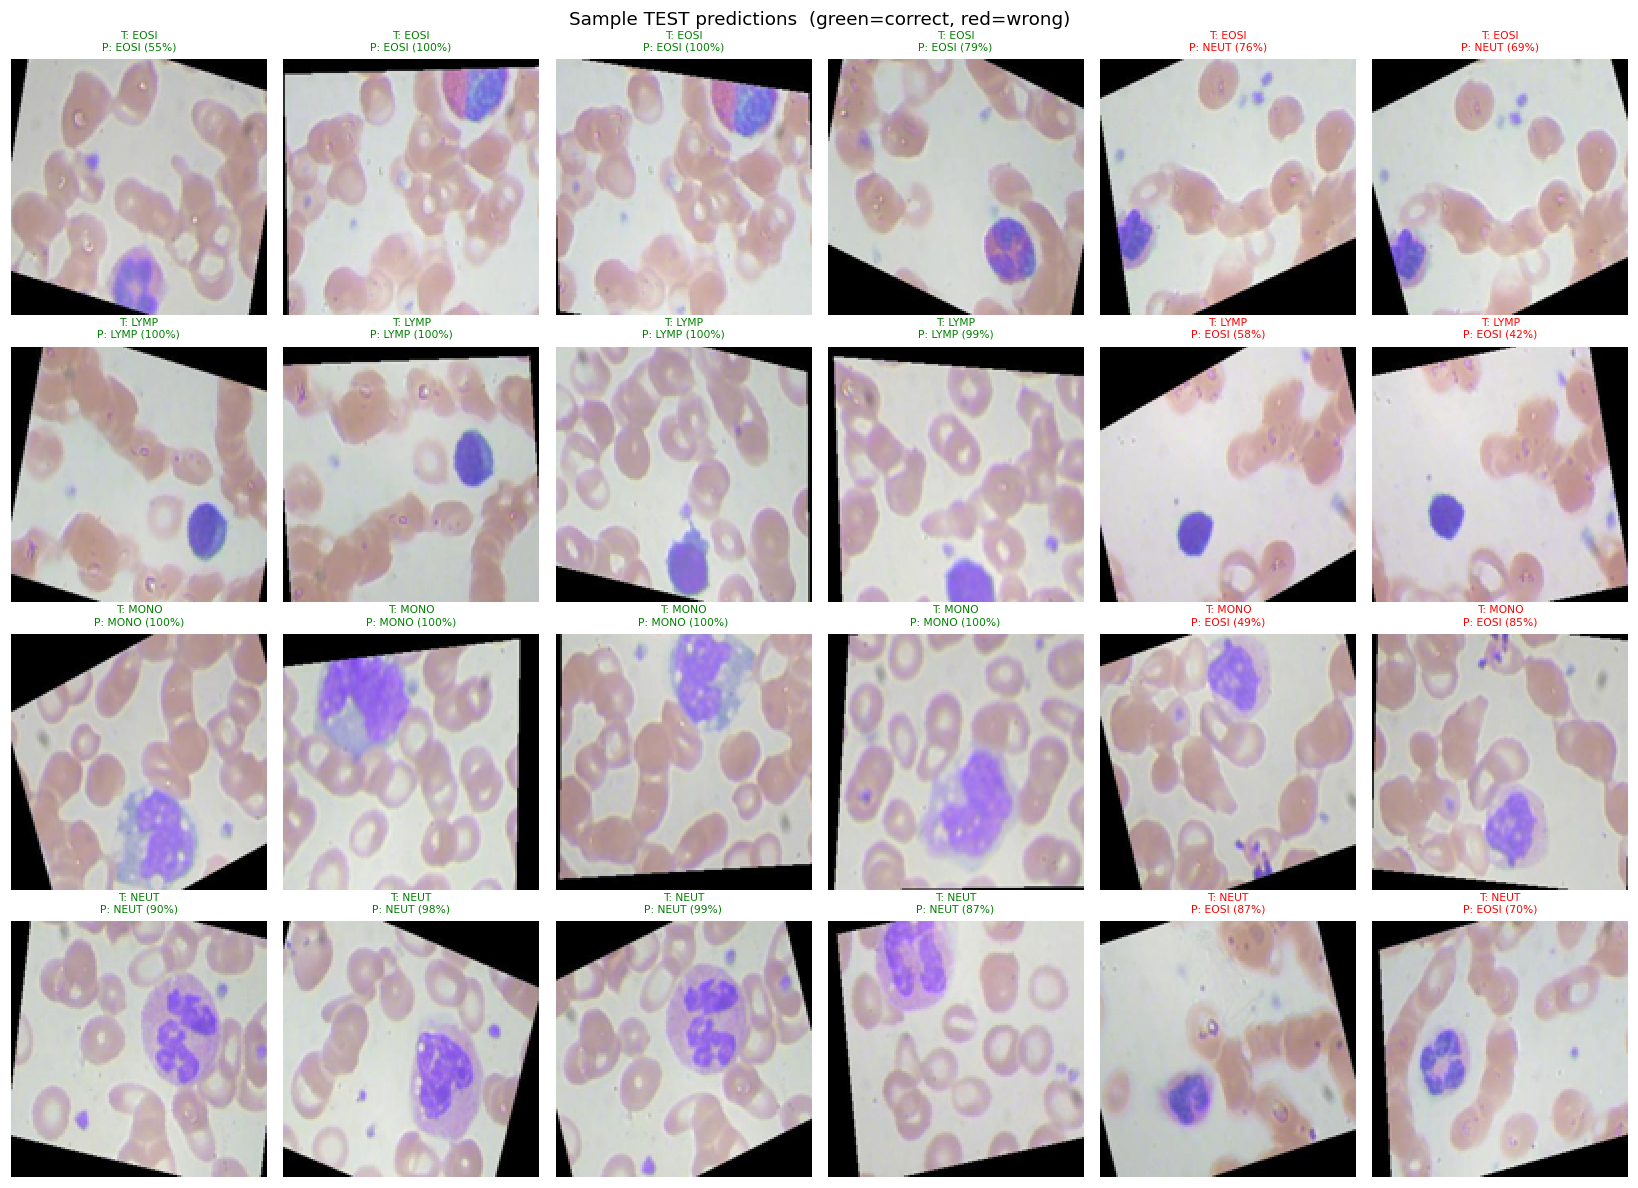

saved -> outputs/figures/phase2_04_sample_predictions.png


In [18]:
# pick 4 correct + 2 wrong predictions (if any) per class to show
filepaths = np.array(test_gen.filepaths)

fig, axes = plt.subplots(4, 6, figsize=(15, 11))

for row, cls_idx in enumerate(range(len(CLASSES))):
    cls_mask    = (y_true == cls_idx)
    correct_idx = np.where(cls_mask & (y_pred == y_true))[0]
    wrong_idx   = np.where(cls_mask & (y_pred != y_true))[0]

    chosen = list(correct_idx[:4]) + list(wrong_idx[:2])
    # pad with correct if not enough wrong
    while len(chosen) < 6:
        chosen.append(correct_idx[len(chosen)])

    for col, idx in enumerate(chosen[:6]):
        img  = np.array(Image.open(filepaths[idx]).resize((128, 128)))
        axes[row, col].imshow(img)
        true_lbl = CLASSES[y_true[idx]]
        pred_lbl = CLASSES[y_pred[idx]]
        conf     = y_pred_proba[idx][y_pred[idx]] * 100
        correct  = (y_true[idx] == y_pred[idx])
        axes[row, col].set_title(
            f'T: {true_lbl[:4]}\nP: {pred_lbl[:4]} ({conf:.0f}%)',
            fontsize=7,
            color='green' if correct else 'red'
        )
        axes[row, col].axis('off')

fig.suptitle('Sample TEST predictions  (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_04_sample_predictions.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_04_sample_predictions.png')

## 6. Results summary & analysis

In [20]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)

best_val_acc   = max(history.history['val_accuracy'])
best_epoch     = history.history['val_accuracy'].index(best_val_acc) + 1
actual_epochs  = len(history.history['loss'])
final_tr_acc   = history.history['accuracy'][-1]
final_val_acc  = history.history['val_accuracy'][-1]
final_tr_loss  = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print('=' * 56)
print('  BASELINE CNN — FINAL RESULTS')
print('=' * 56)
print(f'  Architecture       : 4×Conv2D → Flatten → Dense(64) → Dense(4)')
print(f'  Input size         : {IMG_SIZE[0]}×{IMG_SIZE[1]}×3')
print(f'  Total params       : {total_params:,}')
print(f'  Optimizer          : Adam  lr={LR}')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Max epochs         : {EPOCHS}')
print(f'  Epochs trained     : {actual_epochs}')
print(f'  Best epoch (val)   : {best_epoch}')
print('-' * 56)
print(f'  Final train  loss  : {final_tr_loss:.4f}    acc: {final_tr_acc:.4f}')
print(f'  Final val    loss  : {final_val_loss:.4f}    acc: {final_val_acc:.4f}')
print(f'  Best val accuracy  : {best_val_acc:.4f}')
print('-' * 56)
print(f'  TEST accuracy      : {test_acc:.4f}')
print(f'  TEST precision     : {prec:.4f}')
print(f'  TEST recall        : {rec:.4f}')
print(f'  TEST F1 (macro)    : {f1:.4f}')
print(f'  TEST AUC (macro)   : {np.mean(list(auc_scores.values())):.4f}')
print('=' * 56)

gap = final_tr_acc - final_val_acc
print(f'Train-val accuracy gap : {gap:.4f}')
if gap > 0.10:
    print('-> Clear overfitting (gap > 10%). Expected for baseline with no regularization.')
elif gap > 0.05:
    print('-> Mild overfitting (gap 5-10%).')
else:
    print('-> No significant overfitting detected.')


  BASELINE CNN — FINAL RESULTS
  Architecture       : 4×Conv2D → Flatten → Dense(64) → Dense(4)
  Input size         : 128×128×3
  Total params       : 765,444
  Optimizer          : Adam  lr=0.0001
  Batch size         : 32
  Max epochs         : 30
  Epochs trained     : 30
  Best epoch (val)   : 30
--------------------------------------------------------
  Final train  loss  : 0.0773    acc: 0.9755
  Final val    loss  : 0.1511    acc: 0.9457
  Best val accuracy  : 0.9457
--------------------------------------------------------
  TEST accuracy      : 0.7953
  TEST precision     : 0.8178
  TEST recall        : 0.7955
  TEST F1 (macro)    : 0.8019
  TEST AUC (macro)   : 0.9552
Train-val accuracy gap : 0.0298
-> No significant overfitting detected.


## 7. Analysis

### 7.1 Training behaviour

The model was trained for **30 epochs** (max 30, no early stopping).  
Training accuracy climbed steadily to **97.55%** (loss: `0.0773`) by the final epoch, and validation accuracy reached **94.57%** (loss: `0.1511`) — also at epoch 30, which was the best checkpoint.  
Both curves moved together throughout training with no divergence, indicating a clean learning process.

### 7.2 Overfitting analysis

At the end of training the train–val accuracy gap was **2.98%** (train 97.55% vs val 94.57%).  
→ **No significant overfitting detected.** The validation curve kept improving right up to epoch 30, which is surprisingly clean for a bare baseline with no Dropout, BatchNorm, or augmentation.

However, there is a notable **val–test gap of ~15%** (val acc 94.57% → test acc 79.53%).  
This is not caused by overfitting to the training set — the val score is high. The likely cause is that `ImageDataGenerator`'s `validation_split` takes the **last 20% of files by filename order** (not a truly random split), so the validation set ends up systematically different from the held-out TEST folder.

### 7.3 Test-set evaluation

| Metric | Value |
|---|---|
| Accuracy | **79.53%** |
| Precision (macro) | 81.78% |
| Recall (macro) | 79.55% |
| F1-score (macro) | 80.19% |
| AUC (macro) | **95.52%** |

Despite the lower accuracy, the macro AUC of **95.52%** is strong — the model's confidence scores rank the correct class highly even when the argmax prediction is wrong. This tells us the features learned are useful; the decision boundary just needs refinement.

### 7.4 Per-class performance & class confusion

| Class | Precision | Recall | F1 | AUC |
|---|---|---|---|---|
| EOSINOPHIL | 0.65 | 0.73 | **0.69** | 0.9150 |
| LYMPHOCYTE | 1.00 | 0.93 | **0.96** | 0.9996 |
| MONOCYTE   | 0.97 | 0.76 | **0.85** | 0.9848 |
| NEUTROPHIL | 0.66 | 0.76 | **0.71** | 0.9215 |

**LYMPHOCYTE** is the easiest class by far (F1 = 0.96, AUC ≈ 1.00) — its distinctively large, round, dark nucleus makes it visually unique and easy to separate.  
**EOSINOPHIL** and **NEUTROPHIL** are the hardest, both with F1 ≈ 0.69–0.71. Both are granulocytes with multi-lobed nuclei and similar overall cell size; the model struggles to distinguish them from fine granule staining differences alone — information that low-resolution 128×128 crops partially lose. These two are the most confused pair in the confusion matrix.

### 7.5 Conclusion for this phase

This baseline CNN (765,444 params, no regularization) achieves **79.53% test accuracy** and **95.52% macro AUC**.  
The main weaknesses are:
1. **EOSINOPHIL vs NEUTROPHIL confusion** — granulocyte ambiguity at 128×128.
2. **Val–test distribution gap** — filename-ordered validation split is not truly representative.

These are the targets for the next phases: augmentation, BatchNorm/Dropout, and transfer learning.
